# Ejercicio Reto 1

## Clasificación Naive Bayes


Para la realización del reto #1, se utilizará el modelo Naive Bayes, bajo este modelo se espera cumplir los objetivos principales del caso, los cuales son:   

* Mejorar la gestión del riesgo crédito mediante la **clasificación** de solicitantes de crédito en función de la preaprobación del crédito.   

* Pronosticar la preaprobación del crédito para un grupo de solicitantes que aún no poseen preaprobación.   

Bajo Naive Bayes, se puede hacer una predicción sobre que categorías pertenece un dato basándose en características previas, es por esto por lo que, es el modelo indicado para la construcción del reto.


### 1. Importación de datos

In [35]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

solicitantes = pd.read_excel("/content/drive/MyDrive/EAFIT/0. SolicitantesCrédito.xlsx")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
solicitantes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               8378 non-null   int64  
 1   Edad                     8378 non-null   int64  
 2   Sexo                     8378 non-null   object 
 3   Estado civil             8378 non-null   object 
 4   Hijos                    8378 non-null   int64  
 5   Perscargo                8378 non-null   int64  
 6   Estrato                  8378 non-null   int64  
 7   Nivel de estudios        8378 non-null   object 
 8   Tipo de contrato         8378 non-null   object 
 9   Ingresos                 8378 non-null   int64  
 10  Egresos                  8378 non-null   int64  
 11  Tipo de actividad        8378 non-null   object 
 12  Tipo de vivienda         8378 non-null   object 
 13  Total Activos            8378 non-null   float64
 14  Total pasivos           

### 2. Limpieza de datos

Antes de la aplicación del modelo, se limpian los datos y se determinan cuales son las variables/Caracteristicas (x) que va a trabajar el modelo y cuales son las Etiquetas (y) siendo estas las salidas que se quieren predecir.

In [37]:
solicitantes.shape

(8378, 35)

In [38]:
XD = solicitantes.dropna(subset=['PreApr'])

In [39]:
XD.shape

(5842, 35)

Variables a trabajar: "Edad","Hijos", "Perscargo", "Estrato", "Ingresos", "Egresos" , "Monto (EAD)", "Plazo", "Cuota (COP)"

In [40]:
XD = XD[["Edad","Hijos", "Perscargo", "Estrato", "Ingresos", "Egresos" , "Monto (EAD)", "Plazo", "Cuota (COP)"]]
XD

,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
0,38,1,0,3,5424576,7585302,2.815030e+06,48,82691.506204
1,51,6,1,4,1144064,1640079,6.301439e+05,36,22781.212598
2,37,2,0,3,2069853,2831440,1.280540e+06,36,46294.596244
3,29,1,0,2,1893080,2482276,1.393414e+06,24,69564.950015
4,42,3,4,2,3000367,3630221,2.252986e+06,24,112478.307883
...,...,...,...,...,...,...,...,...,...
8371,48,0,0,3,4831392,3392105,3.366188e+06,36,121695.762156
8373,31,2,0,5,5891088,4292158,3.918572e+06,48,115108.056436
8374,38,0,0,3,3092079,3028098,2.677266e+06,36,96789.562091
8375,43,1,2,2,2542007,3513112,1.375112e+06,36,49713.608249


In [41]:
yd = solicitantes["PreApr"].dropna()

### 3. Implementación del modelo naive bayes

In [42]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [43]:
XDArray = np.array(XD, dtype=float)
ydArray = np.array(yd, dtype=float)

In [44]:
XDArray

array([[3.80000000e+01, 1.00000000e+00, 0.00000000e+00, ...,
        2.81503004e+06, 4.80000000e+01, 8.26915062e+04],
       [5.10000000e+01, 6.00000000e+00, 1.00000000e+00, ...,
        6.30143930e+05, 3.60000000e+01, 2.27812126e+04],
       [3.70000000e+01, 2.00000000e+00, 0.00000000e+00, ...,
        1.28054021e+06, 3.60000000e+01, 4.62945962e+04],
       ...,
       [3.80000000e+01, 0.00000000e+00, 0.00000000e+00, ...,
        2.67726552e+06, 3.60000000e+01, 9.67895621e+04],
       [4.30000000e+01, 1.00000000e+00, 2.00000000e+00, ...,
        1.37511242e+06, 3.60000000e+01, 4.97136082e+04],
       [3.70000000e+01, 1.00000000e+00, 2.00000000e+00, ...,
        4.52536592e+06, 3.60000000e+01, 1.63602819e+05]])

In [45]:
ydArray

array([1., 1., 0., ..., 1., 1., 1.])

Luego de la limpieza de datos, empezamos con el entrenamiento del modelo


In [46]:
from sklearn.naive_bayes import GaussianNB

In [47]:
modeloNB = GaussianNB()

## 1. Entreno al modelo

Luego de limpiar y obtener las respectivas X,Y. estas se introducen en el modelo y comienza a realizar predicciones con las características respecto a las variables puestas de los solicitantes de crédito

In [48]:
modeloNB.fit(XDArray, ydArray)

GaussianNB()

In [49]:
ydPred = modeloNB.predict(XDArray)

## 2. Matriz de confusión

La utilización de la matriz de confusión nos ilustra qué tan bien está clasificado nuestro modelo, nos ayuda a evaluar su presición y que tanto se equivoca en cada categoría.

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [51]:
cm = confusion_matrix(ydArray, ydPred)

In [52]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modeloNB.classes_)

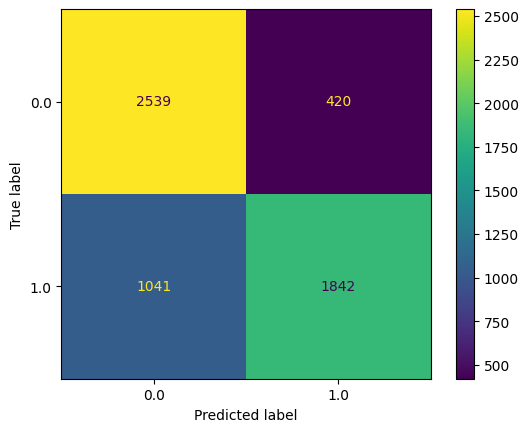

In [53]:
disp.plot()
plt.show()

Una vez obtenido el gráfico de la matriz, pasamos a las métricas de evaluación, explicamos el significado de cada una de estas y comparamos con los rendimientos de las métricas de 4 variables en el modelo Naive Bayes (recordemos que estamos trabajando con 9)

## 3. Métricas de evaluación del modelo

En este punto, explicamos las 4 variables mostradas en el recuadro inferior:   

* VN: Verdaderos Negativos: Hace referencia a las personas que solicitaron un crédito, no eran aptos para otorgarles el préstamo y el modelo determinó que efectivamente no lo eran.   
* FP: Falsos Positivos: Hace referencia a las personas que solicitaron un crédito, no eran aptos para otorgarles el préstamo y el modelo los indicó como aptos.   
* FN: Falsos Negativos: Hace referencia a las personas que solicitaron un crédito, eran aptos para otorgarles el préstamo y el modelo los indicó como no aptos.
* VP: Verdaderos Positivos: Hace referencia a las personas que solicitaron un crédito, eran aptos para otorgarles el préstamo y el modelo determinó efectivamente que si lo eran.   

De entrada podemos ver que los resultados de cada variable fueron:   
* VN: 2539
* FP: 420
* FN: 1041
* VP: 1842

En estos resultados se puede reflejar en los FP y en los FN, las irregularidades del modelo, haciendo más énfasis en los FP, ya que son personas que no son aptas para tener un crédito, significando un riesgo para el deudor para solventarse y el acreedor en el riesgo de ese dinero prestado.   

En comparativa con los datos del ejercicio de 4 variables, podemos evidenciar estas diferencias:
* VN: 2503-2539, Aumento
* FP: 456-420, Reducción
* FN: 938-1041, Aumento
* VP: 1945-1842, Reducción   

Evidenciamos a simple vista que, aunque se reduce la fatalidad en FP y se aumenta el coeficiente VN, permitiendo que no se le preste a personas que puede poner en riesgo el retorno del dinero; se presentan gran aumento en FN, provocando la pérdida de clientes potenciales por falla del modelo y  reducciones en VP, significando un menor margen de personas aptas para el crédito.

Una vez hecho este anílisis inicial, pasaremos con las métricias de evaluación

In [54]:
VN=cm[0,0]
FP=cm[0,1]
FN=cm[1,0]
VP=cm[1,1]

La métrica accuracy nos indica que porcentaje de las predicciones fueron correctas en el modelo sobre el total de las predicciones hechas.   

En este caso, se obtuvo un porcentaje de 74,99% de Accuracy, ilustrado la precisión que tuvo las predicciones.

En comparación con el ejercicio de 4 variables, esta fue su diferencia:

76,14%-74,99%

Esto significa que, en el modelo anterior hubo una mayor precisión en las predicciones hechas que en el modelo trabajado actualmente, dando respaldo a lo comentado en el punto anterior a este.   

In [55]:
exactitud = (VP+VN)/cm.sum()
print(f"La exactitud (accuracy) del modelo es de {exactitud : .2%}")

La exactitud (accuracy) del modelo es de  74.99%


La tasa de error nos indica cuales fueron el # de predicciones incorrectas sobre el total de predicciones realizadas, nos sirve para entender el margen de error que puede llegar a tener el modelo, este seria: 25,01%   

En comparación con el ejercicio de las 4 variables, esta seria su diferencia:

23,86%-25,01%

Como podemos ver, hay un menor margen de error en el modelo anterior a este y guarda lógica con los resultados obtenidos en la exactitud de los modelos.



In [56]:
## Tasa de error
## Número de predicciones incorrectas sobre el total de precciones
error = 1-exactitud
print(f"el error del modelo es de {error : .2%}")

el error del modelo es de  25.01%


La tasa de precisión me mide qué porcentaje de las predicciones **positivas** hechas fueron realmente correctas, este seria: 81,43%  

En comparación con el ejercicio de las 4 variables, esta seria su diferencia:   

81,01%-81,43%   

Aunque hay una una mínima diferencia, en el modelo trabajado actualmente se evidencia una mayor asertividad al otorgar resultados positivos frente al otro modelo, afirmación la cual se puede ver respaldada en las diferencias que hay en los FP.



In [57]:
## Presición
# Que tan cerca está un resultado del valor verdadero. De los el modelo calcula
# como verdaderos, cuales son realmente verdaderos.
presicion = VP/(VP+FP)
print(f"La presición del modelo es de {presicion : .2%}")

La presición del modelo es de  81.43%


La tasa de sensibilidad mide qué tan bien el modelo encuentra los casos positivos dentro de todos los que son realmente positivos. nos muestra de forma porcentual la asertividad de positivos bien clasificados, en el modelo seria: 63,89%

En comparación con el ejercicio de las 4 variables, esta seria su diferencia:

67,46%-63,89

Ilustrandonos que, en el modelo anterior se refleja una mayor positividad bien clasificada con respecto al modelo actual, esto se ve respaldado por el aumento de FN en el modelo actual.

In [58]:
## Sensibilidad (Recall)
# La sensibilidad es la cantidad de positivos bien clasificados por el modelo
# respecto al total de positivos
sensibilidad = VP/(VP+FN)
print(f"La sensibilidad del modelo es de {sensibilidad : .2%}")

La sensibilidad del modelo es de  63.89%


La tasa de especificidad mide de manera porcentual la cantidad de negativos bien clasificados por el modelo con respecto al total de negativos, siendo esta: 85,81%

En comparación con el ejercicio de las 4 variables, esta seria su diferencia:

84,59%-85,81%

Esto nos indica que, en el modelo actual hay una mayor tasa en diferencia al modelo anterior, ilustrando que, hay una mayor cantidad de negativos bien clasificados por parte del modelo actual, esto se puede ver respaldado por la reducción en el FP.


In [59]:
## especificidad
# La cantidad de negativos bien clasificados por el modelo respecto al total de negativos
especificidad = VN/(VN+FP)
print(f"La especificidad del modelo es de {especificidad : .2%}")

La especificidad del modelo es de  85.81%


Una vez terminado los análisis de la matriz y cada métrica, pasamos con el pronostico de la preaprobación para solicitantes nuevos.

## 4. Pronóstico de la preaprobación para solicitantes nuevos

En la contrucción del pronostico, utilizamos los espacios vacios de la columna PreApr, para así, utilizar el modelo actual con su entrenamiento programado para hacer una predicción de como se clasificaria cada una de estas personas que se quedaron en "Hold"  

Así se realizaria las clasificaciones restantes de personas que requieren una respuesta de PreApr, el modelo haria la clasificación de estos individuos de aptos o no aptos según los parámetros impuestos (modeloNB.fit(XDArray, ydArray)) en el entrenamiento realizado en momentos anteriores.

In [60]:
XDGener = solicitantes[solicitantes["PreApr"].isna()]

In [61]:
XDGener = XDGener[["Edad","Hijos", "Perscargo", "Estrato", "Ingresos", "Egresos" , "Monto (EAD)", "Plazo", "Cuota (COP)"]]

In [62]:
XDGenerArray = np.array(XDGener, dtype=float)

In [63]:
ydGener = modeloNB.predict(XDGenerArray)

In [64]:
ydGenerSerie = pd.Series(ydGener, index= solicitantes[solicitantes["PreApr"].isna()].index)

In [65]:
solicitantes["PreApr"].fillna(ydGenerSerie, inplace=True)


<ipython-input-65-c1357dc9852b>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  solicitantes["PreApr"].fillna(ydGenerSerie, inplace=True)


In [66]:
solicitantes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               8378 non-null   int64  
 1   Edad                     8378 non-null   int64  
 2   Sexo                     8378 non-null   object 
 3   Estado civil             8378 non-null   object 
 4   Hijos                    8378 non-null   int64  
 5   Perscargo                8378 non-null   int64  
 6   Estrato                  8378 non-null   int64  
 7   Nivel de estudios        8378 non-null   object 
 8   Tipo de contrato         8378 non-null   object 
 9   Ingresos                 8378 non-null   int64  
 10  Egresos                  8378 non-null   int64  
 11  Tipo de actividad        8378 non-null   object 
 12  Tipo de vivienda         8378 non-null   object 
 13  Total Activos            8378 non-null   float64
 14  Total pasivos           

Una vez realizada la clasificación, se puede descargar el archivo para visualizar el trabajo hecho por el modelo.

In [67]:
solicitantes.to_excel("Solicitantes Prueba Taller.xlsx") #Pasar modificaciones a excel

## 5. Conclusiones

Para concluir con el trabajo, podemos evidenciar diferentes observaciones y reflexiones:

* Aunque en el modelo actual se trabajó con mas variables que en el modelo de 4 variables, se pudo reconocer que, hay una mayor precisión en el modelo de 4 variables, dandonos a entender que el tener mas variables no quiere decir que se pueda llegar a un resultado mas preciso. Al fin y al cabo Naive Bayes es un modelo que considera sus variables cada una independientes; y en un modelo como este el cual muchas de sus variables pueden influir en otras (Estrato, ingresos) se puede llegar a notar mucho ruido provocando que baje su precisión. Esto puede dar una explicación a la respuesta del porque las variables ("Edad", "Ingresos", "Egresos", "Monto (EAD)") logró una mayor precisión en la mayoria de métricas analizadas.  

* Naive Bayes es un modelo útil y rápido para el análisis, predicción de datos y realizar pronosticos en base de, sin embargo, hay que ser cauteloso en el tipo de variables que uno utiliza para el entrenamiento del modelo y a su vez, mantener unas métricas las cuales puedan hacer una retroalimentación sobre como actua este y con que asertividad.  